<a href="https://colab.research.google.com/github/MMujtabaX/BOW/blob/main/BOW_Count_Vector_%26_TFIDF_DS16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Bag of Words (BoW)**

**Bag of Words (BoW)** is a foundational technique in Natural Language Processing (NLP) for representing text data as numerical feature vectors. The core idea is to represent a text (such as a sentence or a document) as a "bag" (multiset) of its words, disregarding grammar and even word order, but keeping track of word frequency.

### How Bag of Words Works

1.  **Tokenization**: The first step is to break down the text into individual words or tokens. This process splits sentences into smaller units, usually words, but can also include phrases or characters.
    -   Example: "The quick brown fox." becomes `["The", "quick", "brown", "fox", "."]`

2.  **Vocabulary Creation**: From the entire collection of texts (corpus), a vocabulary is built. This is a list of all unique words that appear in the corpus.
    -   Example Corpus:
        -   "The cat sat on the mat."
        -   "The dog ate the cat."
    -   Vocabulary: `["The", "cat", "sat", "on", "mat", "dog", "ate"]` (case and punctuation are usually handled in preprocessing)

3.  **Vectorization (Word Counting)**: Each text is then converted into a numerical vector, where each dimension of the vector corresponds to a word in the vocabulary. The value in each dimension typically represents the frequency of that word in the text.
    -   Using the vocabulary above:
        -   "The cat sat on the mat." -> `[2, 1, 1, 1, 1, 0, 0]` (counts for "The", "cat", "sat", "on", "mat", "dog", "ate")
        -   "The dog ate the cat." -> `[2, 1, 0, 0, 0, 1, 1]` (counts for "The", "cat", "sat", "on", "mat", "dog", "ate")

### Key Characteristics

*   **Order Ignored**: The phrase "The dog ate the cat" and "The cat ate the dog" would have identical BoW representations if only word counts are considered, as word order is lost.
*   **Frequency-Based**: The representation primarily relies on how often words appear.
*   **Sparse**: For large vocabularies and short documents, most entries in the vector will be zero.

### Advantages of Bag of Words

*   **Simplicity**: It's easy to understand and implement.
*   **Effectiveness**: Despite its simplicity, it can be very effective for many text classification and analysis tasks, especially when combined with other machine learning algorithms.
*   **Widely Used**: It forms the basis for many more complex text representation models.

### Limitations of Bag of Words

*   **Loss of Context/Semantics**: It ignores the grammatical structure and word order, which means it cannot capture the meaning or context of words (e.g., "not good" is treated the same as "good" if 'not' is removed or not considered).
*   **High Dimensionality**: For a large vocabulary, the feature vector can become very long, leading to the "curse of dimensionality" and requiring more computational resources.
*   **Sparse Representations**: The resulting vectors are often sparse, which can affect the performance of some machine learning models.

### Example Code Using CountVectorizer (Bag of Words):

`CountVectorizer` from `sklearn.feature_extraction.text` is a common way to implement the Bag of Words model in Python.

```python
from sklearn.feature_extraction.text import CountVectorizer

# Sample corpus
corpus = [
    "The cat sat on the mat.",
    "The dog ate the cat.",
    "The cat is a good pet."
]

# Initialize CountVectorizer, which implements Bag of Words
# It tokenizes text and counts word occurrences.
cv_model = CountVectorizer()

# Fit and transform the corpus
X_bow = cv_model.fit_transform(corpus)

# Get the feature names (vocabulary)
vocabulary = cv_model.get_feature_names_out()
print("Vocabulary:", vocabulary)

# Convert the Bag of Words matrix to a dense array and print it
# Each row represents a document, and each column represents a word from the vocabulary.
# The values are the counts of each word in the document.
print("\nBag of Words Matrix (Counts):\n", X_bow.toarray())
```

### Output:

```
Vocabulary: ['a' 'ate' 'cat' 'dog' 'good' 'is' 'mat' 'on' 'pet' 'sat' 'the']

Bag of Words Matrix (Counts):
 [[0 0 1 0 0 0 1 1 0 1 2]
 [0 1 1 1 0 0 0 0 0 0 2]
 [1 0 1 0 1 1 0 0 1 0 1]]
```

In this output:
- The `Vocabulary` shows all unique words found in the corpus.
- The `Bag of Words Matrix` shows the count of each word from the vocabulary in each document. For instance, in the first document, 'the' appears twice, 'cat' once, 'sat' once, etc.

### **Count Vectorizer**
is a simple but effective technique in Natural Language Processing (NLP) that transforms text into a matrix of token counts. The process involves converting the text data into a numerical format that machine learning models can work with. Here's a detailed breakdown of how it works:

### How Count Vectorizer Works

1. **Tokenization**:
   - Count Vectorizer first splits the text into individual tokens (words or phrases). It does this by "tokenizing" the text.
   - For example, the sentence:
     ```
     "Machine learning is amazing"
     ```
     will be tokenized into the following words (tokens):
     ```
     ["Machine", "learning", "is", "amazing"]
     ```

2. **Vocabulary Building**:
   - Once the text is tokenized, the Count Vectorizer builds a **vocabulary** of all unique words across the entire dataset.
   - For example, if you have a dataset with the following sentences:
     - "Machine learning is fun"
     - "Learning is amazing"
     - "Machine learning is everywhere"
     
     The vocabulary might look like this:
     ```
     ['Machine', 'learning', 'is', 'fun', 'amazing', 'everywhere']
     ```

3. **Creating the Feature Matrix**:
   - Count Vectorizer counts how often each word (from the vocabulary) appears in a given document and creates a matrix of these counts. Each row of the matrix corresponds to a document, and each column corresponds to a word in the vocabulary.
   - For example, using the vocabulary from above, the following matrix is generated:
     ```
     Document 1: ["Machine learning is fun"]
     Document 2: ["Learning is amazing"]
     Document 3: ["Machine learning is everywhere"]
     
     Feature Matrix (Token Counts):
     |               | Machine | learning | is | fun | amazing | everywhere |
     |---------------|---------|----------|----|-----|---------|------------|
     | Document 1    |    1    |    1     |  1 |  1  |    0    |     0      |
     | Document 2    |    0    |    1     |  1 |  0  |    1    |     0      |
     | Document 3    |    1    |    1     |  1 |  0  |    0    |     1      |
     ```
   - Here, for **Document 1**, "Machine" occurs once, "learning" occurs once, "is" occurs once, and "fun" occurs once. Words like "amazing" and "everywhere" are not present, so their counts are zero.

4. **Final Output**:
   - The result is a **sparse matrix** that contains the frequency counts of each word across the documents. This matrix can now be used for further analysis or as input for machine learning algorithms.

### Advantages of Count Vectorizer
- **Simple to Use**: Count Vectorizer is easy to understand and implement. It is also a good starting point for text vectorization.
- **Effective for Small Datasets**: It works well when the dataset is not too large and when words are used relatively consistently across documents.

### Limitations of Count Vectorizer
- **Sparse Matrix**: For large corpora, the vocabulary size can become huge, and the matrix will be sparse, meaning most of the elements will be zeros.
- **No Semantic Understanding**: It does not take into account the meaning or context of the words (e.g., "cat" and "cats" will be treated as separate words even though they are related).
- **Sensitive to Stopwords**: Common words (e.g., "the", "is", "and") may dominate the feature matrix without adding much meaning. Preprocessing steps like stopword removal are important to improve its effectiveness.

### Example Code Using CountVectorizer in Python:
```python
from sklearn.feature_extraction.text import CountVectorizer

# Sample corpus (list of documents)
corpus = [
    "Machine learning is fun",
    "Learning is amazing",
    "Machine learning is everywhere"
]

# Initialize CountVectorizer
count_vectorizer = CountVectorizer()

# Fit and transform the corpus to get the count matrix
X_count = count_vectorizer.fit_transform(corpus)

# Display the feature names (vocabulary)
print("Vocabulary:", count_vectorizer.get_feature_names_out())

# Convert the feature matrix to an array and print it
print("Count Vectorizer Matrix:\n", X_count.toarray())
```

### Output:
```
Vocabulary: ['amazing' 'everywhere' 'fun' 'is' 'learning' 'machine']
Count Vectorizer Matrix:
 [[0 0 1 1 1 1]
  [1 0 0 1 1 0]
  [0 1 0 1 1 1]]
```

In this output:
- The vocabulary contains the words `['amazing', 'everywhere', 'fun', 'is', 'learning', 'machine']`.
- The matrix shows how many times each word from the vocabulary appears in each document.

Count Vectorizer is the basis for more complex text representations and can be used with other techniques such as **TF-IDF (Term Frequency-Inverse Document Frequency)**, which assigns higher importance to rarer words.

In [2]:
from sklearn.feature_extraction.text import CountVectorizer

# Sample corpus (list of documents)
corpus = [
    "Machine learning is fun fun",
    "Learning is amazing",
    "Machine learning is everywhere"
]

# Initialize CountVectorizer
count_vectorizer = CountVectorizer()

# Fit and transform the corpus to get the count matrix
X_count = count_vectorizer.fit_transform(corpus)

# Display the feature names (vocabulary)
print("Vocabulary:", count_vectorizer.get_feature_names_out())

# Convert the feature matrix to an array and print it
print("Count Vectorizer Matrix:\n", X_count.toarray())

Vocabulary: ['amazing' 'everywhere' 'fun' 'is' 'learning' 'machine']
Count Vectorizer Matrix:
 [[0 0 2 1 1 1]
 [1 0 0 1 1 0]
 [0 1 0 1 1 1]]


### **TF-IDF (Term Frequency-Inverse Document Frequency)**
is a popular technique in Natural Language Processing (NLP) used for text feature extraction. It transforms text into numerical values, representing the importance of each word within a document in relation to the entire corpus (the set of documents). TF-IDF is particularly effective for text analysis because it reduces the influence of commonly used words (like stopwords) and highlights more important, distinctive terms.

Here's a detailed breakdown of how **TF-IDF** works:

### 1. **Term Frequency (TF)**

The **Term Frequency (TF)** measures how often a word appears in a specific document. Intuitively, the more frequently a word appears, the more relevant it is to that document. However, simply counting the frequency of terms may give undue weight to commonly used words like "the," "and," "is," etc. Hence, TF is usually calculated as:

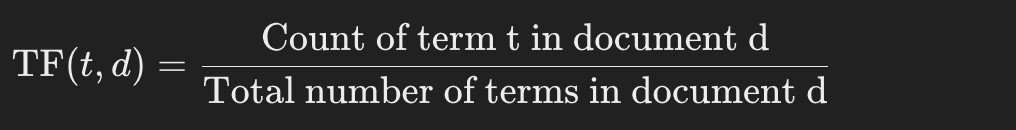
Where:
- \( t \) is the term (word).
- \( d \) is the document.

For example, if the word "machine" appears 3 times in a document that contains 100 words, the **TF** for "machine" in that document would be:

\[
\text{TF}(\text{"machine"}, d) = \frac{3}{100} = 0.03
\]

### 2. **Inverse Document Frequency (IDF)**

The **Inverse Document Frequency (IDF)** is a measure of how important a term is in the entire corpus. Words that appear in many documents are considered less important, as they are not helpful in distinguishing between documents. The IDF of a term is calculated as:

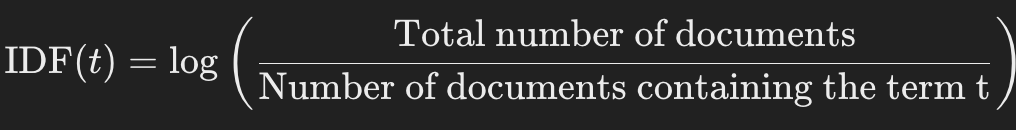
This formula effectively reduces the weight of terms that occur frequently across the corpus (e.g., "the", "is", "and"), and increases the weight of terms that occur less frequently but are more informative.

For example:
- If the term "machine" appears in 5 out of 100 documents, the **IDF** would be:
  
  \[
  \text{IDF}(\text{"machine"}) = \log \left( \frac{100}{5} \right) = \log(20) \approx 1.30
  \]

- If the term "is" appears in 99 out of 100 documents, the **IDF** would be very low:

  \[
  \text{IDF}(\text{"is"}) = \log \left( \frac{100}{99} \right) \approx 0.0043
  \]

### 3. **TF-IDF Calculation**

The final **TF-IDF** score for a term is simply the product of its **Term Frequency (TF)** and **Inverse Document Frequency (IDF)**. This means that terms that appear frequently in a document but rarely across the corpus will have higher scores, making them more relevant to the document.

\[
\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)
\]

Using the previous examples, if "machine" has a TF of 0.03 and an IDF of 1.30, then the TF-IDF for "machine" in the document would be:

\[
\text{TF-IDF}(\text{"machine"}, d) = 0.03 \times 1.30 = 0.039
\]

### 4. **Why TF-IDF is Useful**

- **Reduces the impact of frequent but unimportant words**: Words that appear very frequently across the corpus (like "the", "is", "in") are given low weights because they don't provide useful information to distinguish between documents.
- **Highlights distinctive terms**: Words that are frequent in specific documents but rare across the corpus are given higher weights, making them important for distinguishing the content of the document.

### 5. **Example of TF-IDF Calculation**

Let’s consider a small corpus of three documents:

1. "Machine learning is amazing."
2. "Learning is fun and amazing."
3. "Machine learning is everywhere."

First, let's compute the TF for each term in each document.

#### Term Frequency (TF):

- For Document 1:
  - TF("Machine") = 1/5 = 0.2
  - TF("learning") = 1/5 = 0.2
  - TF("is") = 1/5 = 0.2
  - TF("amazing") = 1/5 = 0.2

- For Document 2:
  - TF("Learning") = 1/6 = 0.17
  - TF("is") = 1/6 = 0.17
  - TF("fun") = 1/6 = 0.17
  - TF("and") = 1/6 = 0.17
  - TF("amazing") = 1/6 = 0.17

#### Inverse Document Frequency (IDF):

- Let's compute the IDF for each term:
  - "Machine" appears in 2 out of 3 documents, so IDF("Machine") = log(3/2) ≈ 0.1761
  - "Learning" appears in all 3 documents, so IDF("Learning") = log(3/3) = 0
  - "is" appears in all 3 documents, so IDF("is") = log(3/3) = 0
  - "amazing" appears in 2 out of 3 documents, so IDF("amazing") = log(3/2) ≈ 0.1761
  - "fun" and "and" each appear in only 1 document, so IDF("fun") = log(3/1) ≈ 1.0986 and IDF("and") = log(3/1) ≈ 1.0986

#### TF-IDF Calculation:

Now, let’s multiply the TF and IDF for each term to get the **TF-IDF** score for each term in each document.

- **Document 1:**
  - TF-IDF("Machine") = 0.2 * 0.1761 ≈ 0.0352
  - TF-IDF("learning") = 0.2 * 0 = 0
  - TF-IDF("is") = 0.2 * 0 = 0
  - TF-IDF("amazing") = 0.2 * 0.1761 ≈ 0.0352

- **Document 2:**
  - TF-IDF("Learning") = 0.17 * 0 = 0
  - TF-IDF("is") = 0.17 * 0 = 0
  - TF-IDF("fun") = 0.17 * 1.0986 ≈ 0.1868
  - TF-IDF("and") = 0.17 * 1.0986 ≈ 0.1868
  - TF-IDF("amazing") = 0.17 * 0.1761 ≈ 0.0299

- **Document 3:**
  - TF-IDF("Machine") = 0.2 * 0.1761 ≈ 0.0352
  - TF-IDF("learning") = 0.2 * 0 = 0
  - TF-IDF("is") = 0.2 * 0 = 0
  - TF-IDF("amazing") = 0.2 * 0.1761 ≈ 0.0352

### 6. **Advantages of TF-IDF**

- **Emphasizes unique terms**: It emphasizes terms that are unique to specific documents and reduces the impact of common words.
- **Balances frequency and uniqueness**: TF-IDF is a balance between the frequency of a term within a document and its rarity across the corpus, which improves the quality of features used in machine learning models.

### 7. **Example Code in Python Using TF-IDF**

```python
from sklearn.feature_extraction.text import TfidfVectorizer

# Sample corpus (list of documents)
corpus = [
    "Machine learning is amazing.",
    "Learning is fun and amazing.",
    "Machine learning is everywhere."
]

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the corpus to get the TF-IDF matrix
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

# Display the feature names (vocabulary)
print("Vocabulary:", tfidf_vectorizer.get_feature_names_out())

# Convert the feature matrix to an array and print it
print("TF-IDF Matrix:\n", X_tfidf.toarray())
```

### Output:

```
Vocabulary: ['amazing' 'and' 'everywhere' 'fun' 'is' 'learning' 'machine']
TF-IDF Matrix:
 [[0.4762 0.         0.         0.         0.4762 0.4762 0.4762]
  [0.4762 0.4762 0.         0.4762 0.4762 0.4762 0.        ]
  [0

### **Comparison Table: Bag of Words, Count Vectorizer, and TF-IDF**

While **Bag of Words (BoW)** is a conceptual model for representing text, **Count Vectorizer** and **TF-IDF** are specific implementations or enhancements of this concept for numerical text representation.

Here's a comparison:

| Feature              | Bag of Words (Concept)                                | Count Vectorizer (Implementation of BoW)                  | TF-IDF (Term Frequency-Inverse Document Frequency)        |
| :------------------- | :---------------------------------------------------- | :-------------------------------------------------------- | :-------------------------------------------------------- |
| **Core Idea**        | Represents text as a multiset of its words, ignoring grammar and order, focusing on word frequency. | Creates a matrix where rows are documents and columns are unique words (vocabulary), with cell values being word counts. | Calculates a score for each word in a document, reflecting its importance by considering both its frequency in the document and its rarity across the corpus. |
| **Output**           | A conceptual numerical representation of text based on word occurrences. | A sparse matrix of integer word counts. Each entry `(i, j)` is the number of times word `j` appears in document `i`. | A sparse matrix of float values. Each entry `(i, j)` is the TF-IDF score for word `j` in document `i`. |
| **Word Order**       | Ignored                                               | Ignored                                                   | Ignored                                                   |
| **Context/Semantics**| Not captured                                          | Not captured                                              | Not captured (beyond statistical importance)              |
| **Weighting Scheme** | Typically simple frequency (count)                    | Simple frequency (count)                                  | Combines Term Frequency (TF) and Inverse Document Frequency (IDF) to assign weights. |
| **Common Use Cases** | Text classification, clustering, information retrieval, feature extraction. | Baseline for text classification, simple document similarity, spam detection. | Document ranking, keyword extraction, text classification, information retrieval. |
| **Handles Stopwords**| No, unless explicitly preprocessed                    | No, unless `stop_words` parameter is used                 | Reduces the weight of common words (like stopwords) implicitly due to IDF. |
| **Sparsity**         | Can be high for large vocabularies                    | High, especially for large vocabularies and short documents. | High, similar to Count Vectorizer, as most words don't appear in all documents. |
| **Interpretability** | Relatively easy to understand counts                  | Easy to interpret (raw word counts)                       | More nuanced interpretation due to combined TF and IDF factors. |
| **Scikit-learn Class**| Not a direct class, but a concept implemented by `CountVectorizer`. | `sklearn.feature_extraction.text.CountVectorizer`       | `sklearn.feature_extraction.text.TfidfVectorizer` (which also handles tokenization and TF calculation) |
| **Advantages**       | Simplicity, foundational to NLP                     | Easy to implement, good for basic analysis                | Captures importance of words, handles common words effectively, often leads to better performance in ML models. |
| **Limitations**      | Ignores word order, high dimensionality, semantic loss. | Ignores word order, high dimensionality, semantic loss, sensitive to common words. | Ignores word order, high dimensionality, semantic loss, still sensitive to rare words. |

**In summary**:

*   **Bag of Words** is the overarching idea of representing text numerically by its word content.
*   **Count Vectorizer** is a direct implementation of the Bag of Words concept, where the value in the vector is simply the raw count of each word.
*   **TF-IDF** is an improvement over simple word counts. It uses the Bag of Words model but assigns weights to words based on their statistical importance within a document and across the entire corpus, making it more effective for many advanced NLP tasks.